In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [6]:
import pandas as pd

# Create a sample Student Placement dataset
data = {
    "Study_Hours": [
        2,3,4,5,6,7,8,9,10,1,
        4,5,6,7,8,2,3,9,10,5,
        6,7,8,4,3,9,10,5,6,7
    ],

    "Attendance": [
        55,60,65,70,75,80,85,90,95,50,
        68,72,78,82,88,58,62,91,96,74,
        79,84,89,69,63,92,97,76,81,86
    ],

    "Project_Done": [
        0,0,0,1,1,1,1,1,1,0,
        0,1,1,1,1,0,0,1,1,1,
        1,1,1,0,0,1,1,1,1,1
    ],

    "Placed": [
        0,0,0,1,1,1,1,1,1,0,
        0,1,1,1,1,0,0,1,1,1,
        1,1,1,0,0,1,1,1,1,1
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display first five rows
df.head()

,Study_Hours,Attendance,Project_Done,Placed
0,2,55,0,0
1,3,60,0,0
2,4,65,0,0
3,5,70,1,1
4,6,75,1,1


In [7]:
print(df)

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

    Study_Hours  Attendance  Project_Done  Placed
0             2          55             0       0
1             3          60             0       0
2             4          65             0       0
3             5          70             1       1
4             6          75             1       1
5             7          80             1       1
6             8          85             1       1
7             9          90             1       1
8            10          95             1       1
9             1          50             0       0
10            4          68             0       0
11            5          72             1       1
12            6          78             1       1
13            7          82             1       1
14            8          88             1       1
15            2          58             0       0
16            3          62             0       0
17            9          91             1       1
18           10          96             1       1


In [8]:
X = df[[
    "Study_Hours",
    "Attendance",
    "Project_Done"
]]

y = df["Placed"]

In [9]:
data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data[[
    "Study_Hours",
    "Attendance",
    "Project_Done"
]]

y = data["Placed"].astype(int)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [11]:
model = GaussianNB()

In [12]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [13]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Actual Results:")
print(y_test.to_numpy())

print("\nPredicted Results:")
print(y_pred)

print(f"\nAccuracy: {accuracy*100:.2f}%")

Actual Results:
[0 1 1 1 0 1 1 0 1]

Predicted Results:
[0 1 1 1 0 1 1 0 1]

Accuracy: 100.00%


In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Placed", "Placed"],
    zero_division=0
))

              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00         3
      Placed       1.00      1.00      1.00         6

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3 0]
 [0 6]]


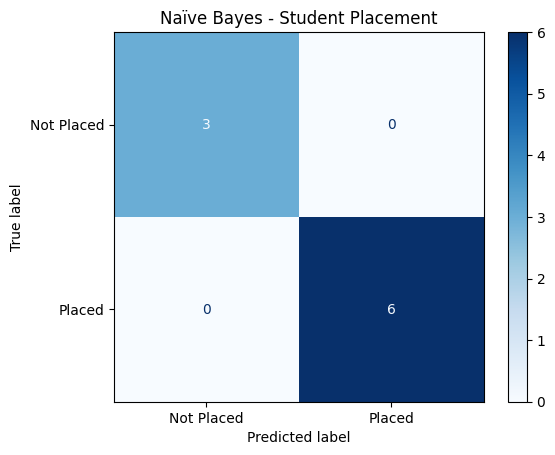

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
)

disp.plot(cmap="Blues")

plt.title("Naïve Bayes - Student Placement")

plt.show()

In [18]:
new_student = [[8, 90, 1]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Placed")
else:
    print("Prediction: Not Placed")

Prediction: Placed


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
